# Model Comparison — Resolution Degradation Curves

**Purpose:** Determine whether the degradation pattern characterised in Experiment 2
(using `yolo26s`) holds across the full model family (`yolo26n`, `yolo26s`, `yolo26m`).
All inference CSVs are already in `results/raw/`; this notebook only loads and analyses them.

**Decision criterion:** If the two primary signals (IDSW/GT-track, MT ratio) collapse at
the same resolution threshold (~576 px) for all three models, the operating-envelope finding
is model-agnostic and can be reported without qualification.  If thresholds diverge, the
single-model analysis in notebook 02 should be reported with an explicit scope caveat.

**Signals (methodology v3):**
- `idsw_per_gt_track` — identity confusion, normalised by GT track count
- `mostly_tracked_ratio` — end-to-end track continuity (80% coverage per GT track)
- Noise floor: ±1-switch band on IDSW, computed per sequence from GT track count

In [1]:
# ── Configuration ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from benchmark.config import (
    DATA_ROOT, RESULTS_RAW, SEQUENCES, SEQ_SUFFIX,
    RESOLUTIONS, IMGSZ_BASE, MODEL_VARIANTS,
)
from benchmark.degradation import detection_stability, track_continuity
from benchmark.mot_gt import load_gt

print(f"Models      : {MODEL_VARIANTS}")
print(f"Sequences   : {SEQUENCES}")
print(f"Resolutions : {RESOLUTIONS}")

# Verify all CSVs are present before doing any computation
missing = []
for model in MODEL_VARIANTS:
    for seq in SEQUENCES:
        for imgsz in RESOLUTIONS:
            p = RESULTS_RAW / f"{seq}_{model}_{imgsz}.csv"
            if not p.exists():
                missing.append(p.name)

if missing:
    print(f"\nMISSING {len(missing)} CSVs — run notebook 02 with each model first:")
    for m in missing:
        print(f"  {m}")
else:
    n_total = len(MODEL_VARIANTS) * len(SEQUENCES) * len(RESOLUTIONS)
    print(f"\nAll {n_total} CSVs present — ready to analyse.")

Models      : ['yolo26n.pt', 'yolo26s.pt', 'yolo26m.pt', 'yolo26l.pt', 'yolo26x.pt']
Sequences   : ['MOT17-09', 'MOT17-02', 'MOT17-04']
Resolutions : [640, 576, 512, 448, 384, 320]

All 90 CSVs present — ready to analyse.


In [2]:
# ── Degradation signal computation (no inference — reads existing CSVs) ────────
#
# For each (model, sequence, resolution) triplet: load the CSV, compute the two
# primary track-continuity signals via track_continuity(), and append to deg_rows.
# Baseline is always the 640-px run of the same (model, sequence) pair.

deg_rows = []

for model in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        baseline_csv = RESULTS_RAW / f"{seq_name}_{model}_{IMGSZ_BASE}.csv"
        seq_dir      = DATA_ROOT / f"{seq_name}-{SEQ_SUFFIX}"

        if not baseline_csv.exists():
            print(f"WARNING: baseline missing for {model} / {seq_name}")
            continue

        for imgsz in RESOLUTIONS:
            csv_path = RESULTS_RAW / f"{seq_name}_{model}_{imgsz}.csv"
            if not csv_path.exists():
                continue

            tc = track_continuity(csv_path, seq_dir)
            deg_rows.append({
                "model":                model,
                "seq":                  seq_name,
                "imgsz":                imgsz,
                "num_switches":         tc["num_switches"],
                "idsw_per_gt_track":    tc["idsw_per_gt_track"],
                "frag_ratio":           tc["frag_ratio"],
                "mostly_tracked_ratio": tc["mostly_tracked_ratio"],
            })
        print(f"  {model} / {seq_name} done")

deg_df = pd.DataFrame(deg_rows)
print(f"\nTotal rows: {len(deg_df)}  (expect {len(MODEL_VARIANTS) * len(SEQUENCES) * len(RESOLUTIONS)})")
print(deg_df[["model", "seq", "imgsz", "idsw_per_gt_track", "mostly_tracked_ratio"]].to_string(index=False))

  yolo26n.pt / MOT17-09 done
  yolo26n.pt / MOT17-02 done
  yolo26n.pt / MOT17-04 done
  yolo26s.pt / MOT17-09 done
  yolo26s.pt / MOT17-02 done
  yolo26s.pt / MOT17-04 done
  yolo26m.pt / MOT17-09 done
  yolo26m.pt / MOT17-02 done
  yolo26m.pt / MOT17-04 done
  yolo26l.pt / MOT17-09 done
  yolo26l.pt / MOT17-02 done
  yolo26l.pt / MOT17-04 done
  yolo26x.pt / MOT17-09 done
  yolo26x.pt / MOT17-02 done
  yolo26x.pt / MOT17-04 done

Total rows: 90  (expect 90)
     model      seq  imgsz  idsw_per_gt_track  mostly_tracked_ratio
yolo26n.pt MOT17-09    640           1.807692              0.615385
yolo26n.pt MOT17-09    576           1.923077              0.615385
yolo26n.pt MOT17-09    512           2.000000              0.615385
yolo26n.pt MOT17-09    448           2.692308              0.500000
yolo26n.pt MOT17-09    384           2.615385              0.384615
yolo26n.pt MOT17-09    320           2.615385              0.346154
yolo26n.pt MOT17-02    640           0.849057              0

In [3]:
# ── Per-sequence normalisation anchored at 640 baseline ───────────────────────
#
# Normalisation is per (model, sequence) pair so each model's curve starts at 0.
# The noise floor depends only on GT track count and the model's own baseline IDSW.

n_gt_by_seq = {
    seq: load_gt(DATA_ROOT / f"{seq}-{SEQ_SUFFIX}")["track_id"].nunique()
    for seq in SEQUENCES
}
print("GT track counts:", n_gt_by_seq)

for model in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        mask     = (deg_df["model"] == model) & (deg_df["seq"] == seq_name)
        baseline = deg_df[mask & (deg_df["imgsz"] == IMGSZ_BASE)]
        if baseline.empty:
            continue

        base_idsw = float(baseline["idsw_per_gt_track"].iloc[0])
        base_mt   = float(baseline["mostly_tracked_ratio"].iloc[0])
        n_gt      = n_gt_by_seq[seq_name]

        # Relative change from 640 baseline (0 = baseline, positive = worse)
        deg_df.loc[mask, "idsw_delta_norm"] = (
            (deg_df.loc[mask, "idsw_per_gt_track"] - base_idsw) / base_idsw
        ).clip(-1, None) if base_idsw > 0 else 0.0

        # Noise floor: ±1 raw switch expressed as fraction of baseline idsw_per_gt_track
        deg_df.loc[mask, "idsw_noise_band"] = (1.0 / n_gt) / base_idsw if base_idsw > 0 else 0.0

        # MT: inverted so positive = degradation (fewer mostly-tracked)
        deg_df.loc[mask, "mt_delta_norm"] = (
            (base_mt - deg_df.loc[mask, "mostly_tracked_ratio"]) / base_mt
        ).clip(-1, None) if base_mt > 0 else 0.0

print("\nPrimary signals (0 = baseline, positive = worse):")
print(deg_df[["model","seq","imgsz","idsw_delta_norm","idsw_noise_band","mt_delta_norm"]].to_string(index=False))

GT track counts: {'MOT17-09': 26, 'MOT17-02': 53, 'MOT17-04': 79}

Primary signals (0 = baseline, positive = worse):
     model      seq  imgsz  idsw_delta_norm  idsw_noise_band  mt_delta_norm
yolo26n.pt MOT17-09    640         0.000000         0.021277       0.000000
yolo26n.pt MOT17-09    576         0.063830         0.021277       0.000000
yolo26n.pt MOT17-09    512         0.106383         0.021277       0.000000
yolo26n.pt MOT17-09    448         0.489362         0.021277       0.187500
yolo26n.pt MOT17-09    384         0.446809         0.021277       0.375000
yolo26n.pt MOT17-09    320         0.446809         0.021277       0.437500
yolo26n.pt MOT17-02    640         0.000000         0.022222       0.000000
yolo26n.pt MOT17-02    576        -0.311111         0.022222       0.090909
yolo26n.pt MOT17-02    512        -0.177778         0.022222       0.272727
yolo26n.pt MOT17-02    448        -0.088889         0.022222       0.272727
yolo26n.pt MOT17-02    384         0.155556    

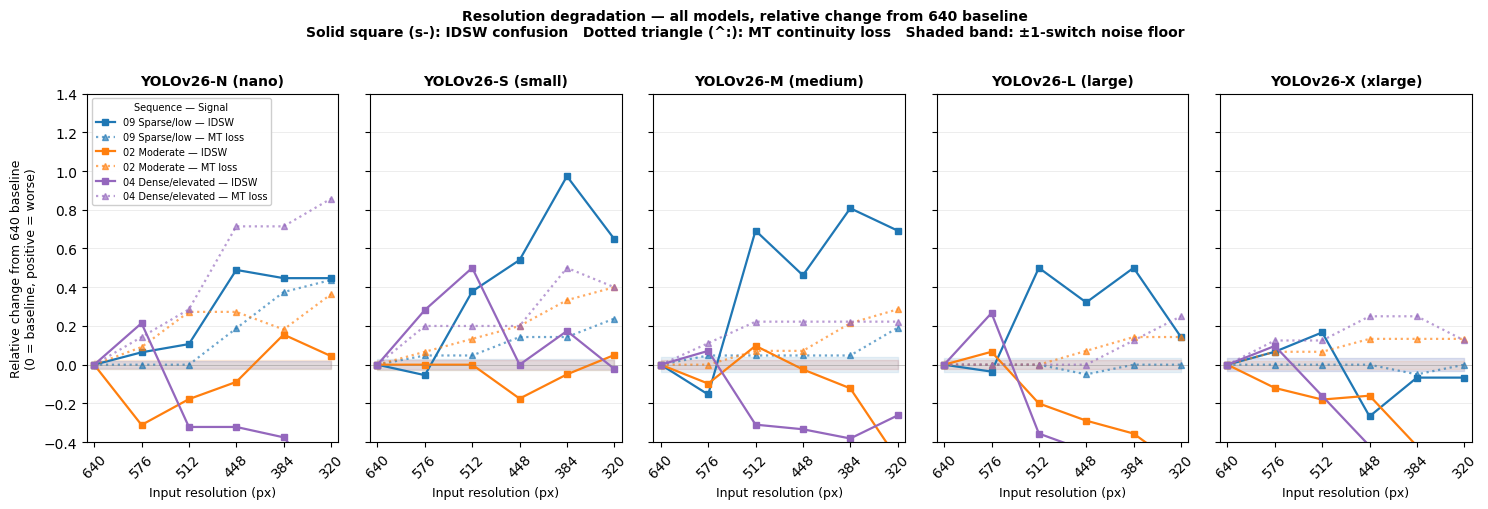

Saved → /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/exp_model_comparison_relative.pdf


In [8]:
# ── Plot A: relative degradation — one column per model, one line per sequence ─
#
# Each subplot shows how IDSW (confusion) and MT loss (continuity) evolve with
# resolution for one model.  Lines are coloured by sequence so trends can be
# compared across models directly.  The ±1-switch noise floor is shown for the
# densest sequence (largest band) as a light red fill — it is conservative and
# applies approximately to all three sequences at similar scale.

SEQ_COLORS = {
    "MOT17-09": "#1f77b4",   # blue  — sparse, low angle
    "MOT17-02": "#ff7f0e",   # orange — moderate elevation
    "MOT17-04": "#9467bd",   # purple — dense, elevated
}
SEQ_LABELS = {
    "MOT17-09": "09 Sparse/low",
    "MOT17-02": "02 Moderate",
    "MOT17-04": "04 Dense/elevated",
}
MODEL_LABELS = {
    "yolo26n.pt": "YOLOv26-N (nano)",
    "yolo26s.pt": "YOLOv26-S (small)",
    "yolo26m.pt": "YOLOv26-M (medium)",
    "yolo26l.pt": "YOLOv26-L (large)",
    "yolo26x.pt": "YOLOv26-X (xlarge)",
}

fig, axes = plt.subplots(1, len(MODEL_VARIANTS), figsize=(15, 5), sharey=True)

for col_idx, model in enumerate(MODEL_VARIANTS):
    ax = axes[col_idx]

    for seq_name in SEQUENCES:
        mask = (deg_df["model"] == model) & (deg_df["seq"] == seq_name)
        sub  = deg_df[mask].sort_values("imgsz", ascending=False)
        if sub.empty:
            continue

        color = SEQ_COLORS[seq_name]
        label = SEQ_LABELS[seq_name]
        band  = float(sub["idsw_noise_band"].iloc[0])

        # IDSW confusion curve (solid square)
        ax.plot(sub["imgsz"], sub["idsw_delta_norm"], "s-",
                color=color, markersize=5, linewidth=1.6,
                label=f"{label} — IDSW")
        # Noise floor band (translucent, matches sequence colour)
        ax.fill_between(sub["imgsz"], -band, band,
                        color=color, alpha=0.10)

        # MT continuity curve (dotted triangle, same colour, lighter)
        ax.plot(sub["imgsz"], sub["mt_delta_norm"], "^:",
                color=color, markersize=5, linewidth=1.6, alpha=0.65,
                label=f"{label} — MT loss")

    ax.axhline(0, color="grey", linewidth=0.6, linestyle="-", alpha=0.4)
    ax.set_title(MODEL_LABELS.get(model, model), fontsize=10, fontweight="bold")
    ax.set_xlim(650, 310)
    ax.set_xticks(RESOLUTIONS)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Input resolution (px)", fontsize=9)
    ax.grid(axis="y", linewidth=0.4, alpha=0.4)
    ax.set_ylim(-0.4, 1.4)
    if col_idx == 0:
        ax.set_ylabel("Relative change from 640 baseline\n(0 = baseline, positive = worse)", fontsize=9)
        ax.legend(fontsize=7, loc="upper left", framealpha=0.95,
                  title="Sequence — Signal", title_fontsize=7)

fig.suptitle(
    "Resolution degradation — all models, relative change from 640 baseline\n"
    "Solid square (s-): IDSW confusion   Dotted triangle (^:): MT continuity loss   "
    "Shaded band: ±1-switch noise floor",
    fontsize=10, fontweight="bold", y=1.01,
)
plt.tight_layout()
out_path = RESULTS_RAW.parent / "figures" / "exp_model_comparison_relative.pdf"
plt.savefig(out_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_path}")

In [6]:
# ── Plot B: Custom Parallel Coordinates via go.Scatter ────────────────────────
#
# go.Parcoords supports only color as a per-line variable (no per-line dash/width).
# Instead, 9 separate go.Scatter traces are drawn over manually positioned vertical
# axes. This enables: colour = sequence hue, dash = model (dot / dash / solid).
#
# Alignment: spines, tick annotations, and data traces all use xref="x" / yref="y".
# Legend dummies use x=[None],y=[None] on the primary axis — no secondary axis
# (confirmed to cause primary traces to vanish in kaleido export).
#
# Typography: Times New Roman throughout (IEEE double-column template).
# Export: HTML + PDF + PNG via kaleido 1.x + system Chrome.

import numpy as np
import plotly.graph_objects as go

IEEE_FONT = "Times New Roman"

# ── Styling maps ──────────────────────────────────────────────────────────────
SEQ_HEX   = {"MOT17-09": "#1f77b4", "MOT17-02": "#e6550d", "MOT17-04": "#756bb1"}
SEQ_LABELS = {
    "MOT17-09": "MOT17-09",
    "MOT17-02": "MOT17-02",
    "MOT17-04": "MOT17-04",
}
MODEL_DASH = {"yolo26n.pt": "dot", "yolo26s.pt": "dash", "yolo26m.pt": "solid", "yolo26l.pt": "longdash", "yolo26x.pt": "longdashdot"}
MODEL_LABELS = {
    "yolo26n.pt": "YOLOv26-N",
    "yolo26s.pt": "YOLOv26-S",
    "yolo26m.pt": "YOLOv26-M",
    "yolo26l.pt": "YOLOv26-L",
    "yolo26x.pt": "YOLOv26-X",
}

# ── Dimension ordering: interleaved IDSW / MT per resolution ─────────────────
dim_keys   = []
dim_titles = []
for res in RESOLUTIONS:
    dim_keys.append(f"idsw_{res}")
    dim_titles.append(f"IDSW {res}px")
    dim_keys.append(f"mt_{res}")
    dim_titles.append(f"MT {res}px")

N_DIMS = len(dim_keys)  # 12

# ── Build flat data table ─────────────────────────────────────────────────────
pcp_rows = []
for model in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        mask = (deg_df["model"] == model) & (deg_df["seq"] == seq_name)
        sub  = deg_df[mask].set_index("imgsz")
        row  = {"model": model, "seq": seq_name}
        for res in RESOLUTIONS:
            row[f"idsw_{res}"] = float(sub.loc[res, "idsw_per_gt_track"])
            row[f"mt_{res}"]   = float(sub.loc[res, "mostly_tracked_ratio"])
        pcp_rows.append(row)

df_pcp = pd.DataFrame(pcp_rows)

# ── Per-dimension min/max for normalisation ───────────────────────────────────
dim_min = {k: df_pcp[k].min() for k in dim_keys}
dim_max = {k: df_pcp[k].max() for k in dim_keys}

def norm(val, k):
    lo, hi = dim_min[k], dim_max[k]
    return (val - lo) / (hi - lo) if hi > lo else 0.5

x_pos = list(range(N_DIMS))  # integer positions 0–11

# ── Build figure ─────────────────────────────────────────────────────────────
fig = go.Figure()

for _, row in df_pcp.iterrows():
    y_norm = [norm(row[k], k) for k in dim_keys]
    fig.add_trace(go.Scatter(
        x=x_pos, y=y_norm,
        mode="lines+markers",
        marker=dict(size=4, color=SEQ_HEX[row["seq"]]),
        line=dict(color=SEQ_HEX[row["seq"]], dash=MODEL_DASH[row["model"]], width=1),
        showlegend=False,
        hovertemplate=(
            "<b>" + SEQ_LABELS[row["seq"]] + "</b><br>" +
            MODEL_LABELS[row["model"]] + "<extra></extra>"
        ),
    ))

# ── Legend dummies on primary axis ────────────────────────────────────────────
for seq_name in SEQUENCES:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="lines",
        line=dict(color=SEQ_HEX[seq_name], width=2),
        name=SEQ_LABELS[seq_name], legendgroup="seq", showlegend=True,
    ))
for model in MODEL_VARIANTS:
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="lines",
        line=dict(color="grey", dash=MODEL_DASH[model], width=2),
        name=MODEL_LABELS[model], legendgroup="model", showlegend=True,
    ))

# ── Vertical axis spines in data coordinates ─────────────────────────────────
shapes = []
for xp in x_pos:
    shapes.append(dict(
        type="line", xref="x", yref="y",
        x0=xp, x1=xp, y0=0.0, y1=1.0,
        line=dict(color="black", width=0.8),
    ))

# ── Tick + label annotations ──────────────────────────────────────────────────
annotations = []
N_TICKS = 3
for i, k in enumerate(dim_keys):
    lo, hi = dim_min[k], dim_max[k]
    for t in range(N_TICKS):
        frac = t / (N_TICKS - 1)
        val  = lo + frac * (hi - lo)
        annotations.append(dict(
            x=x_pos[i], y=frac, xref="x", yref="y",
            text=f"{val:.2f}", showarrow=False,
            xanchor="right", yanchor="middle",
            font=dict(size=7, color="#555", family=IEEE_FONT),
            xshift=-6,
        ))
    # Axis label just below the bottom of the spine (y=0 in data coords)
    annotations.append(dict(
        x=x_pos[i], y=0, xref="x", yref="y",
        text=dim_titles[i], showarrow=False,
        xanchor="center", yanchor="top",
        font=dict(size=9, family=IEEE_FONT),
        yshift=-8,
    ))

fig.update_layout(
    shapes=shapes,
    annotations=annotations,
    paper_bgcolor="white",
    plot_bgcolor="white",
    xaxis=dict(visible=False, range=[-0.5, N_DIMS - 0.5]),
    yaxis=dict(visible=False, range=[-0.05, 1.05]),
    title=dict(
        text=(
            "<b>Parallel Coordinates — resolution degradation per (model, sequence)</b><br>"
            "<sup>Each line = one (model × sequence) pair · "
            "IDSW/GT-track and MT ratio at each resolution step · "
            "colour = sequence · dash = model</sup>"
        ),
        x=0.5, xanchor="center", y=0.99,
        font=dict(size=12, family=IEEE_FONT),
    ),
    legend=dict(
        orientation="v",
        x=1.01, xanchor="left",
        y=0.5,  yanchor="middle",
        font=dict(size=9, family=IEEE_FONT),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="lightgrey", borderwidth=1,
        tracegroupgap=8,
    ),
    width=1200, height=420,
    margin=dict(l=30, r=200, t=60, b=60),
    font=dict(family=IEEE_FONT, size=9),
)

# ── Export ────────────────────────────────────────────────────────────────────
out_dir  = RESULTS_RAW.parent / "figures"
out_html = out_dir / "exp_model_comparison_pcp.html"
out_pdf  = out_dir / "exp_model_comparison_pcp.pdf"
out_png  = out_dir / "exp_model_comparison_pcp.png"

fig.write_html(str(out_html), include_plotlyjs="cdn")
fig.write_image(str(out_pdf))
fig.write_image(str(out_png))

print(f"Saved HTML → {out_html}")
print(f"Saved PDF  → {out_pdf}")
print(f"Saved PNG  → {out_png}")
fig.show()

Saved HTML → /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/exp_model_comparison_pcp.html
Saved PDF  → /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/exp_model_comparison_pcp.pdf
Saved PNG  → /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/exp_model_comparison_pcp.png


In [7]:
# ── Summary table: operating envelope per model ────────────────────────────────
#
# For each (model, sequence): the resolution at which idsw_delta_norm first
# exceeds the noise floor (IDSW onset) and mt_delta_norm first exceeds 0.1
# (MT onset — 10% continuity loss from baseline).
# A consistent onset across models → model-agnostic operating envelope.

MT_THRESHOLD = 0.10  # 10% MT loss from baseline considered meaningful

rows = []
for model in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        mask  = (deg_df["model"] == model) & (deg_df["seq"] == seq_name)
        sub   = deg_df[mask].sort_values("imgsz", ascending=False)  # 640 → 320
        if sub.empty:
            continue

        band = float(sub["idsw_noise_band"].iloc[0])

        # First resolution (counting down from 640) where signal exceeds threshold.
        # "ascending=False" ordering means rows run 640 → 320; iterrows() finds
        # the first drop from baseline.
        idsw_onset = next(
            (int(r["imgsz"]) for _, r in sub.iterrows()
             if r["imgsz"] < IMGSZ_BASE and r["idsw_delta_norm"] > band),
            None,
        )
        mt_onset = next(
            (int(r["imgsz"]) for _, r in sub.iterrows()
             if r["imgsz"] < IMGSZ_BASE and r["mt_delta_norm"] > MT_THRESHOLD),
            None,
        )

        rows.append({
            "model":       MODEL_LABELS.get(model, model),
            "sequence":    seq_name,
            "idsw_onset_px": idsw_onset if idsw_onset else "none",
            "mt_onset_px":   mt_onset   if mt_onset   else "none",
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

    model sequence idsw_onset_px mt_onset_px
YOLOv26-N MOT17-09           576         448
YOLOv26-N MOT17-02           384         512
YOLOv26-N MOT17-04           576         576
YOLOv26-S MOT17-09           512         448
YOLOv26-S MOT17-02           320         512
YOLOv26-S MOT17-04           576         576
YOLOv26-M MOT17-09           512         320
YOLOv26-M MOT17-02           512         384
YOLOv26-M MOT17-04           576         576
YOLOv26-L MOT17-09           512        none
YOLOv26-L MOT17-02           576         384
YOLOv26-L MOT17-04           576         384
YOLOv26-X MOT17-09           576        none
YOLOv26-X MOT17-02          none         448
YOLOv26-X MOT17-04           576         576


## Interpretation guide

| Observation | Implication |
|---|---|
| Onset thresholds match across all three models | Operating envelope is model-agnostic → report 576 px without model qualification |
| Nano degrades earlier than small/medium | Larger backbone provides measurable robustness → scope finding to small+ |
| Only MT diverges; IDSW onset stable | Confusion mechanism is resolution-driven; continuity depends on backbone capacity |
| Curves are visually congruent (shape, not just onset) | Resolution is the dominant factor; model size is a second-order effect |

Use **Plot A** to compare curve shapes across models at a glance.  
Use **Plot B** for absolute values and annotation-level detail per (sequence, model) cell.  
Use the **summary table** to extract onset thresholds for the paper.